# Model A — A11 à A13 : forecast officiel 2026 et packaging

## Objectif et configuration figée

Champion sélectionné avant inspection 2026 : historical_global + historical_median, equal pour occurrence/growth, CORE. Runner-up : même occurrence + historical_mean, sensibilité uniquement. Aucune sélection, récence, feature ou méthode d'incertitude modifiée après calcul.

P1 est l'**Indice médian de contribution attendue des transitions à la croissance annualisée du loyer effectif des unités à échéance**. Son calcul opérationnel est 100×médiane(p×g), avec g historique médian : estimateur robuste, pas espérance conditionnelle exacte. Le périmètre reste celui de la fondation.

In [1]:
from pathlib import Path
import sys,hashlib,subprocess,json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks':ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from src.models.model_a import estimate_2026,backtest,champion_config
from src.features.model_a_features import assert_foundation_reference
from src.explainability.model_a_explainability import export_model_a_reports,validate_aggregate_payload
frozen=['docs/modeling_contract.md','src/features/model_dataset.py','src/evaluation/backtest.py','src/same_unit.py','src/rent_economics.py','src/external_data.py']
protected=[ROOT/p for p in frozen]+list((ROOT/'data/raw').glob('*.csv'))+list((ROOT/'data/external').glob('*.csv'))
protected+=list((ROOT/'notebooks').glob('0[1-8]_*.ipynb'))+[ROOT/'notebooks/starter.ipynb']
protected+=[ROOT/p for p in ['docs/model_a_features.md','docs/model_a_modeling.md','docs/model_a_selection.md','src/features/model_a_features.py','src/evaluation/model_a_tournament.py','src/evaluation/model_a_evaluation.py','src/models/model_a_occurrence.py','src/models/model_a_growth.py']]
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
for p in frozen:
    assert subprocess.run(['git','show','foundation-v1:'+p],cwd=ROOT,capture_output=True,check=True).stdout==(ROOT/p).read_bytes()
print('Configuration figée :',json.dumps(champion_config(),ensure_ascii=False))
leases=pd.read_csv(ROOT/'data/raw/equinoxe_lease_history.csv',dtype={'sPropCode':'string','sUnitCode':'string'})
display(assert_foundation_reference(leases))
report=estimate_2026(leases,None,return_details=True)
validate_aggregate_payload(report)


Configuration figée : {"occurrence_method": "historical_global", "growth_method": "historical_median", "recency_variant": {"occurrence": "equal", "growth": "equal"}, "feature_set": "core"}


,year,candidates,observed_units,prediction_origin
0,2023,405,401.0,2022-12-31
1,2024,645,634.0,2023-12-31
2,2025,856,773.0,2024-12-31
3,2026,931,NaN,2025-12-31


## Cohorte 2026 et coupure

Origine : 2025-12-31, échéances contractuelles en 2026 déjà connues. Les fins de bail futures contractuellement connues ne sont pas des observations futures. Seuls les baux commencés et signés au cutoff entrent dans l'historique ou le stock candidat. Un écart de cohorte arrête l'API, sans correction silencieuse.

Le champion actuel est un modèle au niveau portefeuille ; les segments décrivent la composition de la cohorte, mais ne modifient pas directement la prédiction. Les catégories bedrooms de moins de cinq unités sont regroupées ; aucun dossier individuel.

In [2]:
print('Unités :',report['cohort']['n_units'])
for dimension in ['province','building','bedrooms','expiry_month']:
    counts=report['cohort'][dimension]
    display(pd.DataFrame([{'dimension':dimension,'segment':k,'unités':v,'part_pct':100*v/931} for k,v in counts.items()]))


Unités : 931


,dimension,segment,unités,part_pct
0,province,Quebec,810,87.003222
1,province,Ontario,121,12.996778


,dimension,segment,unités,part_pct
0,building,Saint-Elzear,268,28.786251
1,building,Le Carlyle,180,19.334049
2,building,Westpark,159,17.078410
3,building,Daniel-Johnson,128,13.748657
4,building,The Met,121,12.996778
5,building,Levesque,75,8.055854


,dimension,segment,unités,part_pct
0,bedrooms,2,544,58.431794
1,bedrooms,1,316,33.941998
2,bedrooms,0,49,5.263158
3,bedrooms,3,22,2.363050


,dimension,segment,unités,part_pct
0,expiry_month,1,38,4.081633
1,expiry_month,2,52,5.585392
2,expiry_month,3,65,6.981740
3,expiry_month,4,62,6.659506
4,expiry_month,5,91,9.774436
5,expiry_month,6,143,15.359828
6,expiry_month,7,90,9.667025
7,expiry_month,8,91,9.774436
8,expiry_month,9,108,11.600430
9,expiry_month,10,61,6.552095


## Occurrence et croissance conditionnelle

Occurrence : 2 372 observations historiques qualifiées, 2 259 transitions et 113 non-transitions, 782 labels en attente exclus. Taux global p=95,2361 %, identique pour les 931 unités.

Growth : 2 259 observations positives qualifiées ; moyenne par unité/année des transitions admissibles alors connues, comme dans la sélection. Médiane g=2,56588 %, identique pour toutes les unités. Les champs effectifs des deux baux, leurs débuts pour l'annualisation et leurs signatures/fins pour la maturité sont nécessaires. La qualification est conditionnelle à la fidélité CRM ; les dates ne prouvent pas un journal de versions.

In [3]:
display(pd.DataFrame([report['components']]))


,historical_transition_probability,historical_conditional_growth,contribution_fraction,unit,constant_across_units,n_history_occurrence,n_transitions,n_non_transitions,pending_labels,n_history_growth,growth_q05_pct,growth_q95_pct,history_year_min,history_year_max,qualification
0,0.952361,0.025659,0.024436,fractions,True,2372,2259,113,782,2259,-5.229188,11.25472,2018,2025,Baux commencés et signés à D ; labels mûrs sel...


## P1 et sensibilité runner-up

Contribution=p×g en fraction ; BASE=100×médiane des contributions. Aucune personnalisation par bâtiment/chambres. Le runner-up utilise la moyenne historique à la place de la médiane ; il est calculé après le champion et ne le remplace jamais.

In [4]:
print(f"BASE officiel : {report['predicted_growth']:.2f} %")
display(pd.DataFrame([report['runner_up_sensitivity']]))
assert report['predicted_growth']==report['forecast']['base']
assert np.isclose(report['predicted_growth'],100*report['components']['contribution_fraction'])


BASE officiel : 2.44 %


,forecast_pct,difference_pp,configuration,interpretation
0,2.652965,0.20932,"{'occurrence_method': 'historical_global', 'gr...",Sensibilité moyenne versus médiane ; ne rempla...


## Scénarios LOW / BASE / HIGH

Méthode inchangée : 1 000 bootstraps des unités, seed=42, q10/q90 ; E=max des erreurs absolues du champion en 2023/2024/2025, soit 1,661326381 pp. LOW=q10−E, BASE=P1, HIGH=q90+E. **Scénarios**, sans garantie de couverture probabiliste.

Le bootstrap transversal n'ajoute pas de largeur car le champion applique une contribution identique à chaque unité ; l'incertitude présentée provient donc de l'erreur historique de backtest.

In [5]:
display(pd.DataFrame([report['forecast']]))
display(pd.DataFrame([report['uncertainty']]))
f=report['forecast'];assert f['low']<=f['base']<=f['high']
assert report['uncertainty']['bootstrap_width_pp']==0


,low,base,high,unit
0,0.782318,2.443645,4.104971,pourcentage


,LOW,BASE,HIGH,bootstrap_q10_pct,bootstrap_q90_pct,signed_errors_pp,model_error_radius_pp,n_bootstrap,random_state,interpretation,risk_factors,bootstrap_width_pp,method,not_captured,bootstrap_explanation
0,0.782318,2.443645,4.104971,2.443645,2.443645,"[0.8339574018200802, 1.6613263810901402, -0.33...",1.661326,1000,42,Scénarios de composition + enveloppe empirique...,[Dérive du taux de transition observée en 2025...,0.0,LOW=q10−E ; BASE=P1 ; HIGH=q90+E ; E=max des e...,"[Dérive future, Changements réglementaires, Dé...",Le bootstrap transversal n'ajoute pas de large...


## Backtests et explicabilité

Le champion est recalculé selon les mêmes règles historiques ; la méthode finale n'exécute pas de nouveau tournoi. Moyenne des scores à poids égal des trois années. Les vrais drivers sont p historique, g médian, éligibilité de cohorte et comportement du backtest. Les caractéristiques physiques et bâtiments ne génèrent pas de différences de forecast.

La méthode médiane avait un MAE pratiquement équivalent à la moyenne et une pire erreur annuelle/RMSE plus faibles, à simplicité identique. Cette justification provient de A9 et n'est pas réévaluée après 2026.

In [6]:
annual=pd.DataFrame(report['backtest_by_year'].values())
display(annual.drop(columns='configuration').round(6))
display(pd.DataFrame([report['aggregate_metrics']]))
print(json.dumps({'drivers':report['drivers'],'risk_factors':report['risk_factors'],'limitations':report['limitations']},ensure_ascii=False,indent=2))
np.testing.assert_allclose(annual.predicted_P1_pct,[2.8700597508977657,3.2691787873371383,2.9693278810997157],atol=1e-10)
np.testing.assert_allclose(annual.realized_P1_pct,[2.0361023490776855,1.607852406246998,3.3008784572648096],atol=1e-10)


,year,prediction_origin,predicted_P1_pct,realized_P1_pct,error_pp,absolute_error_pp,candidate_units,observed_units,n_train_occurrence,n_train_growth,pending_labels,occurrence_brier
0,2023,2022-12-31,2.870060,2.036102,0.833957,0.833957,405,401,897,882,351,0.009826
1,2024,2023-12-31,3.269179,1.607852,1.661326,1.661326,645,634,1246,1227,407,0.016767
2,2025,2024-12-31,2.969328,3.300878,-0.331551,0.331551,856,773,1657,1627,641,0.093779


,mae_pp,rmse_pp,bias_pp,worst_year_pp
0,0.942278,1.090171,0.721244,1.661326


{
  "drivers": [
    {
      "name": "Probabilité historique qualifiée",
      "value": 0.9523608768971332,
      "unit": "fraction",
      "reason": "Taux global des labels occurrence disponibles à la coupure."
    },
    {
      "name": "Croissance conditionnelle médiane",
      "value": 0.02565881139972113,
      "unit": "fraction",
      "reason": "Médiane des croissances annualisées admissibles, agrégées par unité/année historique."
    },
    {
      "name": "Éligibilité de cohorte",
      "value": 931,
      "unit": "unités",
      "reason": "Dernier bail connu avec échéance contractuelle en 2026 ; cohorte figée."
    },
    {
      "name": "Comportement de backtest",
      "value": 1.6613263810901402,
      "unit": "points de pourcentage",
      "reason": "Erreur historique maximale déterminant le rayon des scénarios."
    }
  ],
  "risk_factors": [
    "Dérive du taux de transition observée en 2025",
    "Seulement trois années de backtest et sélection non imbriquée",
    "Fid

## Packaging et figures finales

Trois JSON contiennent uniquement résultats agrégés et méthodologie. Deux figures : backtests/erreurs annuelles et scénarios 2026. L'API estimate_2026(leases, asking, external=None, *, return_details=False) retourne un pourcentage scalaire par défaut. Asking/external restent des arguments de compatibilité sans utilisation prédictive ; starter inchangé.

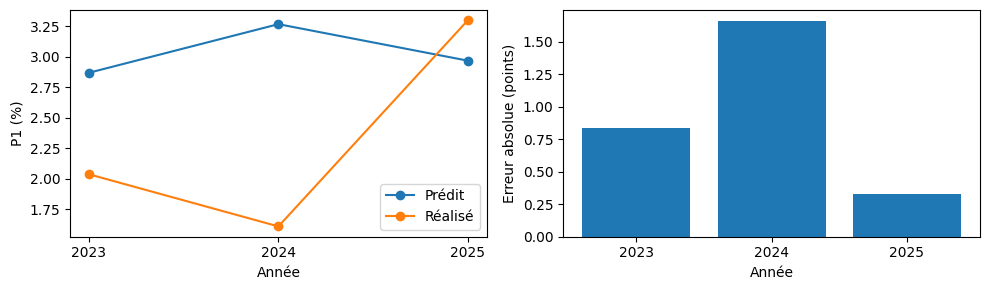

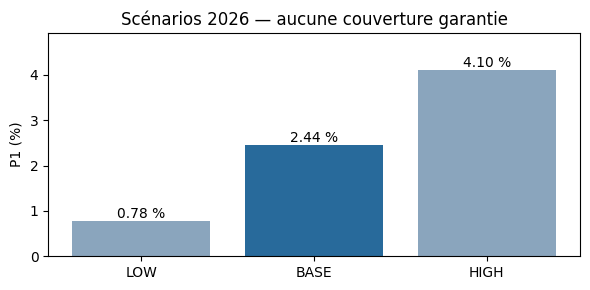

Rapports agrégés et figures créés.


In [7]:
paths=export_model_a_reports(report,ROOT/'outputs/reports')
fig_dir=ROOT/'outputs/figures';fig_dir.mkdir(parents=True,exist_ok=True)
fig,axes=plt.subplots(1,2,figsize=(10,3))
axes[0].plot(annual.year,annual.predicted_P1_pct,marker='o',label='Prédit')
axes[0].plot(annual.year,annual.realized_P1_pct,marker='o',label='Réalisé')
axes[0].set_ylabel('P1 (%)');axes[0].legend()
axes[1].bar(annual.year,annual.absolute_error_pp);axes[1].set_ylabel('Erreur absolue (points)')
for ax in axes:ax.set_xticks([2023,2024,2025]);ax.set_xlabel('Année')
fig.tight_layout();fig.savefig(fig_dir/'model_a_backtest.png',dpi=150);plt.show()
fig,ax=plt.subplots(figsize=(6,3))
values=[f['low'],f['base'],f['high']]
ax.bar(['LOW','BASE','HIGH'],values,color=['#8aa5bd','#286a9b','#8aa5bd'])
for i,v in enumerate(values):ax.text(i,v,f'{v:.2f} %',ha='center',va='bottom')
ax.set_ylabel('P1 (%)');ax.set_title('Scénarios 2026 — aucune couverture garantie')
ax.set_ylim(min(0,min(values)),max(values)*1.2)
fig.tight_layout();fig.savefig(fig_dir/'model_a_2026_scenarios.png',dpi=150);plt.show()
for path in paths:
    payload=json.loads(Path(path).read_text());validate_aggregate_payload(payload)
    assert 'UNIT_KEY' not in Path(path).read_text()
print('Rapports agrégés et figures créés.')


## Risques, limites et conclusion Model A

Dérive occurrence 2025, trois années de backtest, maturité/censure et fidélité CRM non prouvée. Le bootstrap ne couvre pas les nouveaux chocs, réglementations, dépendances ou erreurs structurelles. Les scénarios ne sont pas des intervalles de confiance.

P1 n'est pas la croissance complète du rent roll, occupancy, vacancy, NOI ou tous les loyers. Le champion ne produit pas d'hétérogénéité prédictive entre unités. La médiane conditionnelle n'est pas une espérance exacte.

**Model A complet : BASE 2,44 %, scénarios 0,78 % / 2,44 % / 4,10 %, sensibilité moyenne 2,65 %.** Configuration conservée après inspection 2026 ; prêt à une comparaison A/B sur le même indice, les mêmes cohortes, origines et références.

In [8]:
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==v for p,v in hashes.items())
assert not subprocess.run(['git','diff','--cached','--name-only'],cwd=ROOT,capture_output=True,check=True).stdout
print('Validation finale : fondation et données inchangées ; aucun label 2026, export individuel ou CRM staged.')


Validation finale : fondation et données inchangées ; aucun label 2026, export individuel ou CRM staged.
